In [2]:
import os.path as op
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import mne
from mne_bids import BIDSPath, read_raw_bids
from mne.preprocessing import ICA

In [ ]:
#setting up preprocessing function

#takes input from all raw data files
#looks for bad channels and identifies them
#removes bad channels and saves comparison plots
#removes line noise and 44Hz noise, as well as applies highpass lowpass filters
#applies ICA to remove eye blinks and heartbeats
#saves cleaned data to derivatives folder



In [6]:
subject = '01'
session = '01'
task = 'face'
run = '01'
meg_suffix = 'meg'
ica_suffix = 'ica'

deriv_root = '/Users/rekaforgo/Documents/Bachelor2025/derivatives'

bids_path = BIDSPath(subject=subject, session=session, datatype='meg',
            task=task, run=run,
            root=deriv_root, extension='.fif', check=False)

deriv_fname = bids_path.basename.replace(ann_suffix, ica_suffix)
deriv_file_1 = op.join(bids_path.directory, deriv_fname)
deriv_file_2 = deriv_file_1.replace('run-01', 'run-02')
deriv_files = [deriv_file_1, deriv_file_2]  

print(bids_path)
print(deriv_file_1)

/Users/rekaforgo/Documents/Bachelor2025/derivatives/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01
/Users/rekaforgo/Documents/Bachelor2025/derivatives/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01


In [8]:
# Update bids_path to point to the raw data location instead of derivatives
raw_bids_path = BIDSPath(subject=subject, session=session, datatype='meg',
                        task=task, run=run,
                        root='/Users/rekaforgo/Documents/Bachelor2025',  # Adjust this to your actual BIDS root
                        extension='.fif', check=False)

for subfile in range(2):
    raw = read_raw_bids(bids_path=raw_bids_path, 
                     extra_params={'preload':True},
                     verbose=True)
    raw_resmpl = raw.copy().pick('meg')
    raw_resmpl.resample(200) # dowsample to 200 Hz
    raw_resmpl.filter(1, 40) # band-pass filtert from 1 to 40 Hz
    if subfile == 0:
        raw_resmpl_all = mne.io.concatenate_raws([raw_resmpl])
        bids_path.update(run='02')
    else:
        raw_resmpl_all = mne.io.concatenate_raws([raw_resmpl_all, raw_resmpl])
del raw_resmpl

Resolving symbolic link: /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_meg.fif -> /Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif
Opening raw data file /Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif...
Isotrak not found
    Range : 0 ... 325339 =      0.000 ...   325.339 secs
Ready.


/var/folders/0y/tt7d7wj97hbf8tnc9hnp1_f00000gn/T/ipykernel_2856/3297198670.py:8: RuntimeWarning: This filename (/Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = read_raw_bids(bids_path=raw_bids_path,


Reading 0 ... 325339  =      0.000 ...   325.339 secs...
Reading events from /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_events.tsv.
Reading channel info from /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_channels.tsv.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 661 samples (3.305 s)

Resolving symbolic link: /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_meg.fif -> /Users/

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
/var/folders/0y/tt7d7wj97hbf8tnc9hnp1_f00000gn/T/ipykernel_2856/3297198670.py:8: RuntimeWarning: This filename (/Users/rekaforgo/Documents/Bachelor2025/.git/annex/objects/1J/0p/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif/SHA256E-s84601620--67d9042189a96cc5e0ec779398e79d35abe3a8c35bf36bbeace49bcf6158afda.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = read_raw_bids(bids_path=raw_bids_path,


Reading channel info from /Users/rekaforgo/Documents/Bachelor2025/sub-01/ses-01/meg/sub-01_ses-01_task-face_run-01_channels.tsv.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 661 samples (3.305 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


In [9]:
ica = ICA(method='fastica',
    random_state=97,
    n_components=30,
    verbose=True)

ica.fit(raw_resmpl_all,
    verbose=True)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 30 components
Fitting ICA took 44.5s.


/var/folders/0y/tt7d7wj97hbf8tnc9hnp1_f00000gn/T/ipykernel_2856/920499643.py:6: RuntimeWarning: Using n_components=30 (resulting in n_components_=30) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (5e-09) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 2
  ica.fit(raw_resmpl_all,


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,648 iterations on raw data (130136 samples)
ICA components,30
Available PCA components,64
Channel types,mag
ICA components marked for exclusion,—


Creating RawArray with float64 data, n_channels=30, n_times=130136
    Range : 0 ... 130135 =      0.000 ...   650.675 secs
Ready.
Using matplotlib as 2D backend.


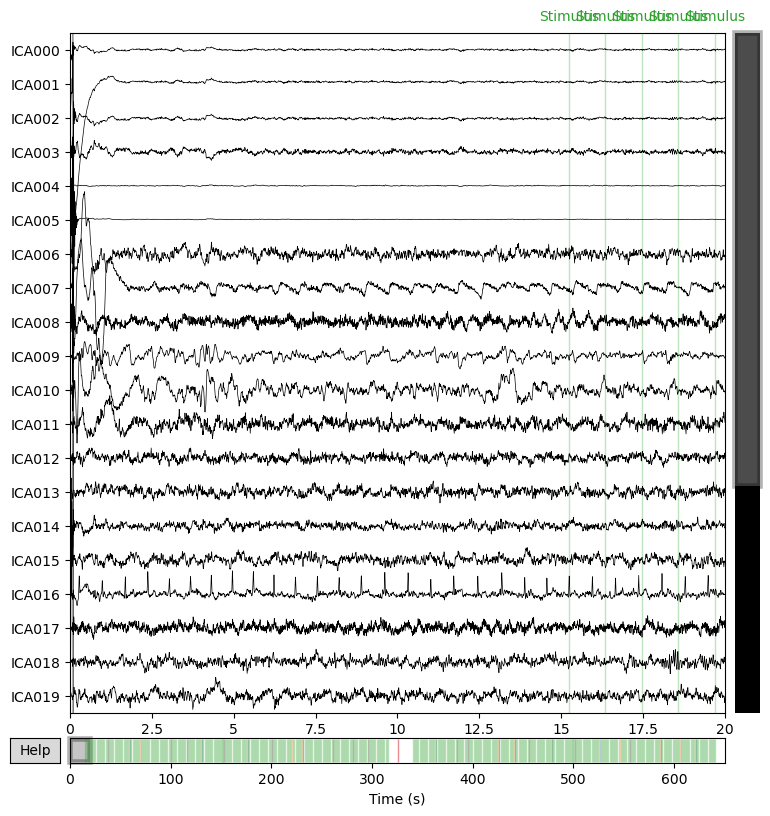

In [10]:
%matplotlib inline
ica.plot_sources(raw_resmpl_all, title='ICA');

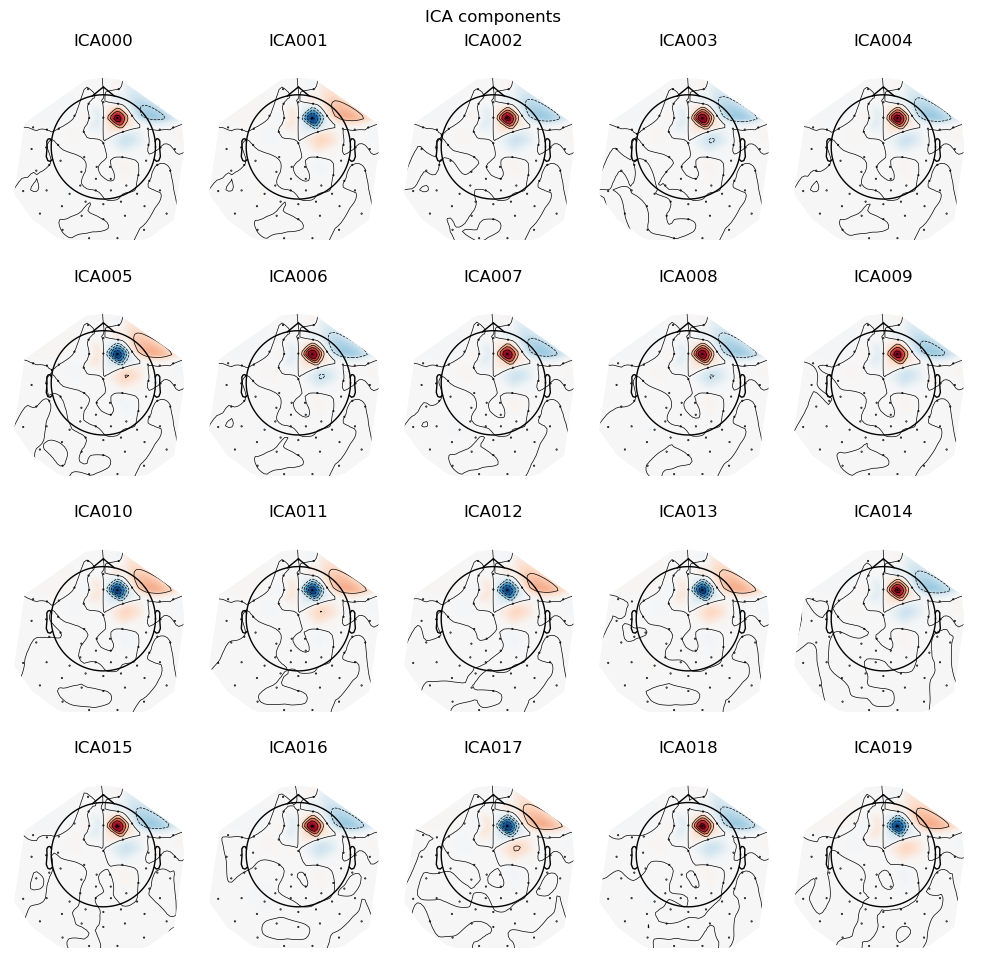

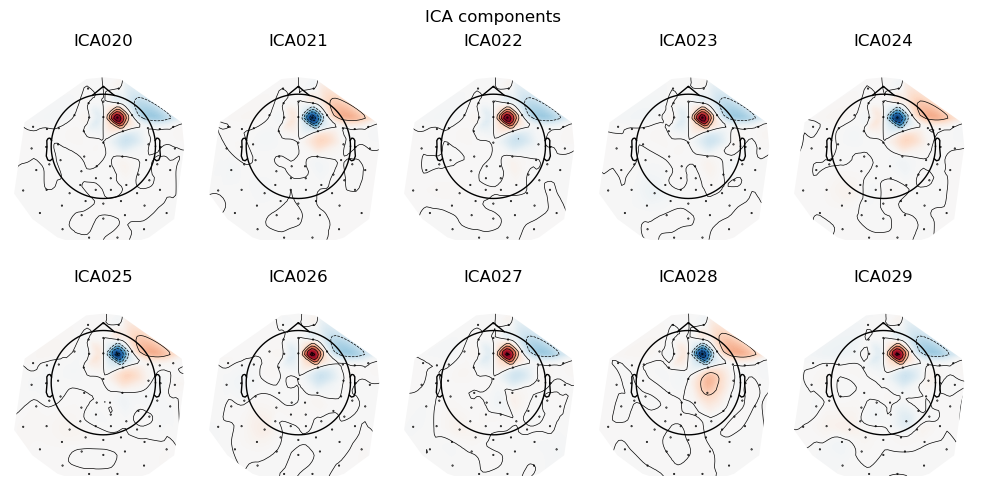

In [11]:
%matplotlib inline
ica.plot_components();

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rekaforgo/Documents/Bachelor2025/derivatives/sub-01/ses-01/meg'